<a href="https://colab.research.google.com/github/soft-ash/DS422_Lab/blob/main/DS422_%E2%80%93_Lab_1_Linear_Regression_%26_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DS422 – Lab 1: Linear Regression & Gradient Descent**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

***Study hours vs exam score dataset (20 samples)***

In [ ]:
data = {
    "Hours_Studied": [1.2, 2.5, 3.1, 4.0, 1.8, 5.2, 6.3, 2.1, 7.5, 4.7,
                      8.2, 3.8, 9.1, 5.9, 6.8, 2.9, 7.1, 4.3, 8.7, 9.6],

    "Exam_Score": [42, 51, 57, 65, 45, 70, 78, 48, 84, 62,
                   88, 59, 93, 74, 81, 54, 85, 61, 91, 96]
}

In [ ]:
df = pd.DataFrame(data)
df

,Hours_Studied,Exam_Score
0,1.2,42
1,2.5,51
2,3.1,57
3,4.0,65
4,1.8,45
5,5.2,70
6,6.3,78
7,2.1,48
8,7.5,84
9,4.7,62


### ***Figure 1 – Dataset scatter plot***



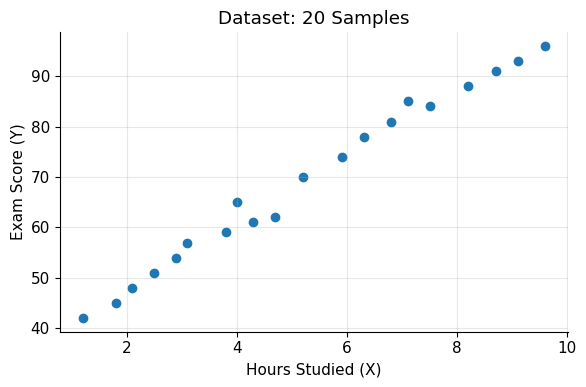

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    df["Hours_Studied"],
    df["Exam_Score"],
    c="tab:blue"
)

ax.set(
    xlabel="Hours Studied (X)",
    ylabel="Exam Score (Y)",
    title="Dataset: 20 Samples"
)

ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("fig1_dataset.png", dpi=200)

plt.show()

## ***Part 1: Linear Regression (scikit-learn)***

In [ ]:
X = df[["Hours_Studied"]]   # Feature
y = df["Exam_Score"]        # Target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Complete!")
print("Slope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)

Model Training Complete!
Slope (m): 6.479095595351678
Intercept (c): 35.475807724779834


In [ ]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Hours": X_test.values.ravel(),
    "Actual": y_test.values,
    "Predicted": y_pred
})

results

,Hours,Actual,Predicted
0,1.2,42,43.250722
1,4.3,61,63.335919
2,2.9,54,54.265185
3,2.5,51,51.673547


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1.886202855567637
R2 Score: 0.9594364977297283


***Lab task: predict for 3 different inputs***

In [ ]:
new_hours = pd.DataFrame({
    "Hours_Studied": [3, 7.5, 9]
})

new_hours["Predicted_Score"] = model.predict(new_hours)

new_hours

,Hours_Studied,Predicted_Score
0,3.0,54.913095
1,7.5,84.069025
2,9.0,93.787668


### ***Figure 2 – Concept of linear regression (line, slope, intercept, residuals)***

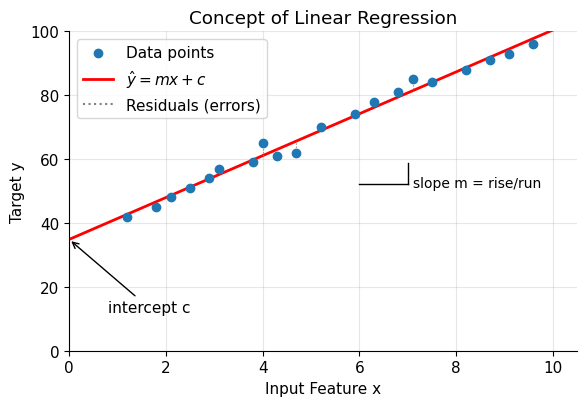

In [ ]:
# Fit regression line using all 20 samples
full = LinearRegression().fit(
    df[["Hours_Studied"]],
    df["Exam_Score"]
)

m = full.coef_[0]
c = full.intercept_

hours = df["Hours_Studied"].values
score = df["Exam_Score"].values

xs = np.linspace(0, 10.5, 50)

fig, ax = plt.subplots(figsize=(6, 4.2))

# Data points
ax.scatter(
    hours,
    score,
    c="tab:blue",
    zorder=3,
    label="Data points"
)

# Regression line
ax.plot(
    xs,
    m * xs + c,
    "r",
    lw=2,
    label=r"$\hat{y}=mx+c$"
)

# Residuals
for x, y_value in zip(hours, score):
    ax.plot(
        [x, x],
        [y_value, m * x + c],
        color="gray",
        lw=0.8,
        ls=":"
    )

ax.plot(
    [],
    [],
    color="gray",
    ls=":",
    label="Residuals (errors)"
)

# Intercept
ax.annotate(
    "intercept c",
    xy=(0, c),
    xytext=(0.8, 12),
    arrowprops=dict(arrowstyle="->")
)

# Slope triangle
o = -22

ax.plot(
    [6, 7],
    [m * 6 + c + o] * 2,
    "k",
    lw=1
)

ax.plot(
    [7, 7],
    [m * 6 + c + o, m * 7 + c + o],
    "k",
    lw=1
)

ax.text(
    7.1,
    m * 6.3 + c + o - 3,
    "slope m = rise/run",
    fontsize=10
)

ax.set(
    xlabel="Input Feature x",
    ylabel="Target y",
    title="Concept of Linear Regression",
    xlim=(0, 10.5),
    ylim=(0, 100)
)

ax.legend(loc="upper left")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("fig2_lr_concept.png", dpi=200)

plt.show()

### ***Figure 3 – Linear Regression Train/Test Result***

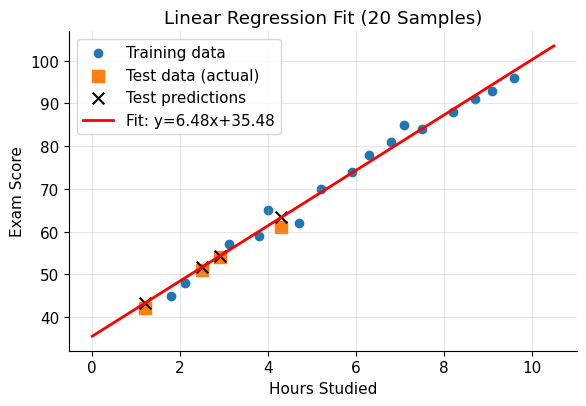

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.2))

# Training data
ax.scatter(
    X_train,
    y_train,
    c="tab:blue",
    label="Training data"
)

# Actual test data
ax.scatter(
    X_test,
    y_test,
    c="tab:orange",
    s=70,
    marker="s",
    label="Test data (actual)"
)

# Test predictions
ax.scatter(
    X_test,
    y_pred,
    c="k",
    marker="x",
    s=70,
    label="Test predictions"
)

# Regression line
ax.plot(
    xs,
    model.coef_[0] * xs + model.intercept_,
    "r",
    lw=2,
    label=f"Fit: y={model.coef_[0]:.2f}x+{model.intercept_:.2f}"
)

ax.set(
    xlabel="Hours Studied",
    ylabel="Exam Score",
    title="Linear Regression Fit (20 Samples)"
)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("fig4_lr_result.png", dpi=200)

plt.show()

## ***Part 2 – Gradient Descent From Scratch***
### ***Figure 3 – Concept of Gradient Descent***

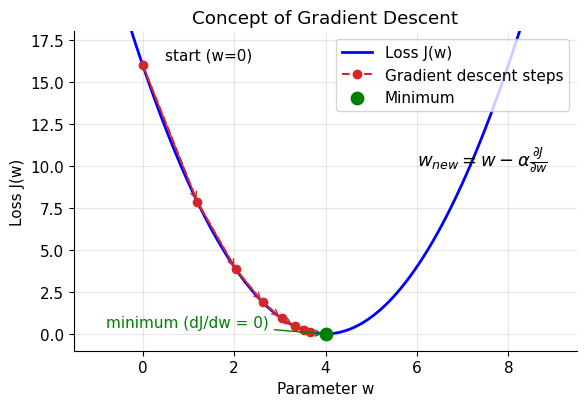

In [ ]:
wv = np.linspace(-1, 9, 200)

L = (wv - 4) ** 2

pts = [0.0]

lr_demo = 0.15

for _ in range(7):
    pts.append(
        pts[-1] - lr_demo * 2 * (pts[-1] - 4)
    )

pl = [(p - 4) ** 2 for p in pts]

fig, ax = plt.subplots(figsize=(6, 4.2))

# Loss curve
ax.plot(
    wv,
    L,
    "b",
    lw=2,
    label="Loss J(w)"
)

# Gradient descent steps
ax.plot(
    pts,
    pl,
    "o--",
    color="tab:red",
    label="Gradient descent steps"
)

# Arrows
for i in range(len(pts) - 1):
    ax.annotate(
        "",
        xy=(pts[i + 1], pl[i + 1]),
        xytext=(pts[i], pl[i]),
        arrowprops=dict(
            arrowstyle="->",
            color="tab:red"
        )
    )

# Minimum
ax.scatter(
    [4],
    [0],
    c="green",
    s=80,
    zorder=5,
    label="Minimum"
)

ax.annotate(
    "minimum (dJ/dw = 0)",
    xy=(4, 0),
    xytext=(-0.8, 0.4),
    color="green",
    arrowprops=dict(
        arrowstyle="->",
        color="green"
    )
)

ax.text(
    0.5,
    pl[0] + 0.3,
    "start (w=0)"
)

ax.text(
    6.0,
    10,
    r"$w_{new}=w-\alpha\frac{\partial J}{\partial w}$",
    fontsize=13
)

ax.set(
    xlabel="Parameter w",
    ylabel="Loss J(w)",
    title="Concept of Gradient Descent",
    ylim=(-1, 18)
)

ax.legend(loc="upper right")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("fig3_gd_concept.png", dpi=200)

plt.show()

In [ ]:
X_gd = df["Hours_Studied"].values
y_gd = df["Exam_Score"].values

w = 0.0
b = 0.0

learning_rate = 0.01
epochs = 1000

n = len(X_gd)

loss_history = []

In [ ]:
for i in range(epochs):

    # Predictions
    y_pred_gd = w * X_gd + b

    # Error
    error = y_pred_gd - y_gd

    # Gradients
    dw = (2 / n) * np.sum(error * X_gd)
    db = (2 / n) * np.sum(error)

    # Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # Calculate MSE loss
    loss = np.mean(error ** 2)

    loss_history.append(loss)

    if i % 100 == 0:
        print(
            f"Epoch {i}, "
            f"Loss: {loss:.3f}, "
            f"w: {w:.3f}, "
            f"b: {b:.3f}"
        )

print(
    f"\nFinal: w = {w:.4f}, "
    f"b = {b:.4f}, "
    f"final loss = {loss_history[-1]:.3f}"
)

Epoch 0, Loss: 5066.100, w: 8.088, b: 1.384
Epoch 100, Loss: 101.733, w: 10.099, b: 12.093
Epoch 200, Loss: 50.412, w: 9.006, b: 19.113
Epoch 300, Loss: 25.869, w: 8.250, b: 23.967
Epoch 400, Loss: 14.131, w: 7.727, b: 27.324
Epoch 500, Loss: 8.517, w: 7.366, b: 29.646
Epoch 600, Loss: 5.833, w: 7.116, b: 31.251
Epoch 700, Loss: 4.549, w: 6.943, b: 32.361
Epoch 800, Loss: 3.935, w: 6.823, b: 33.129
Epoch 900, Loss: 3.641, w: 6.741, b: 33.660

Final: w = 6.6839, b = 34.0242, final loss = 3.502


### ***Figure 5 – Loss Over Epochs***

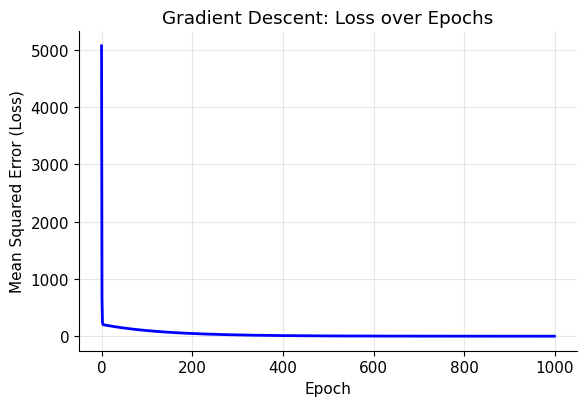

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.2))

ax.plot(
    loss_history,
    "b",
    lw=2
)

ax.set(
    xlabel="Epoch",
    ylabel="Mean Squared Error (Loss)",
    title="Gradient Descent: Loss over Epochs"
)

ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("fig5_gd_loss.png", dpi=200)

plt.show()

### ***Figure 6 – Gradient Descent vs Scikit-Learn***

sklearn         : m = 6.5552, c = 34.8505
Gradient Descent: w = 6.6839, b = 34.0242


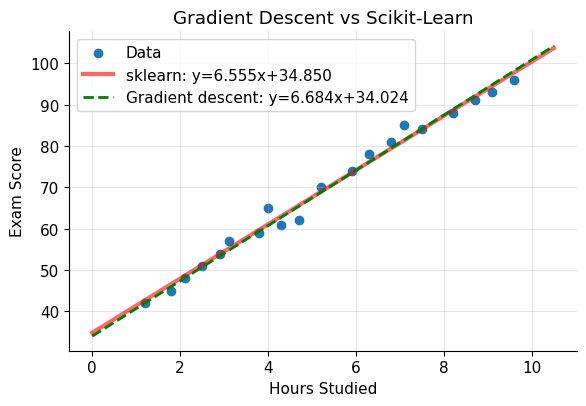

In [ ]:
print(
    "sklearn         : "
    f"m = {m:.4f}, c = {c:.4f}"
)

print(
    "Gradient Descent: "
    f"w = {w:.4f}, b = {b:.4f}"
)

fig, ax = plt.subplots(figsize=(6, 4.2))

# Dataset
ax.scatter(
    X_gd,
    y_gd,
    c="tab:blue",
    label="Data"
)

# Scikit-learn line
ax.plot(
    xs,
    m * xs + c,
    "r",
    lw=3,
    alpha=0.6,
    label=f"sklearn: y={m:.3f}x+{c:.3f}"
)

# Gradient descent line
ax.plot(
    xs,
    w * xs + b,
    "g--",
    lw=2,
    label=f"Gradient descent: y={w:.3f}x+{b:.3f}"
)

ax.set(
    xlabel="Hours Studied",
    ylabel="Exam Score",
    title="Gradient Descent vs Scikit-Learn"
)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("fig6_gd_vs_sklearn.png", dpi=200)

plt.show()

***`Download all report figures`***

In [ ]:
import glob, zipfile
files = sorted(glob.glob("fig*.png"))
print("Saved figures:", files)

try:
    from google.colab import files as colab_files
    with zipfile.ZipFile("report_figures.zip", "w") as z:
        for f in files:
            z.write(f)
    colab_files.download("report_figures.zip")
except ImportError:
    print("Not running in Colab - the PNG files are in the current folder.")

Saved figures: ['fig1_dataset.png', 'fig2_lr_concept.png', 'fig3_gd_concept.png', 'fig4_lr_result.png', 'fig5_gd_loss.png', 'fig6_gd_vs_sklearn.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>